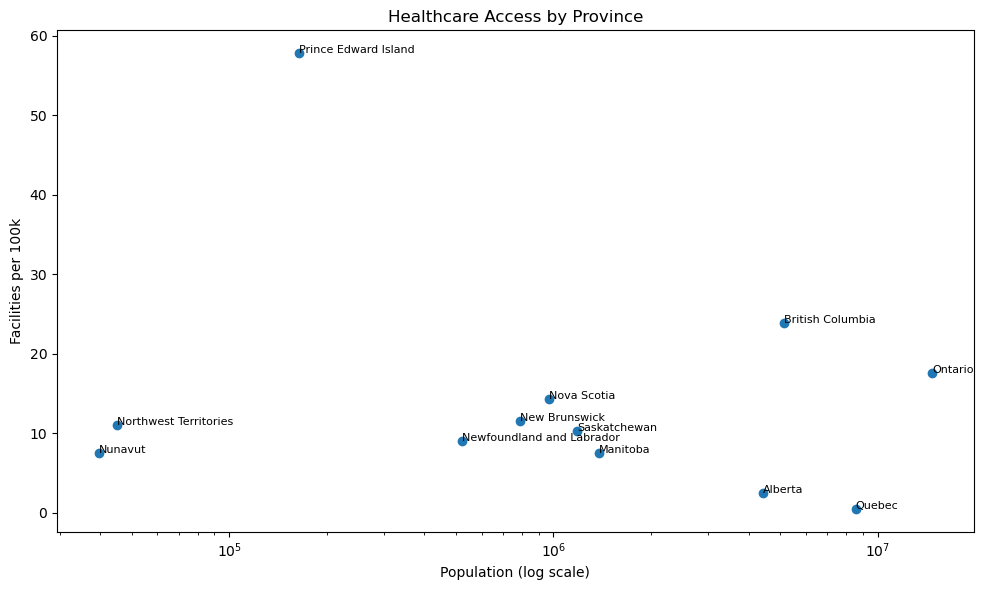

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

fac = pd.read_csv('clean_healthcare_facilities.csv')
pop = pd.read_csv('canada_population.csv')

province_map = {
    'AB': 'Alberta',
    'BC': 'British Columbia',
    'MB': 'Manitoba',
    'NB': 'New Brunswick',
    'NL': 'Newfoundland and Labrador',
    'NS': 'Nova Scotia',
    'NT': 'Northwest Territories',
    'NU': 'Nunavut',
    'ON': 'Ontario',
    'PE': 'Prince Edward Island',
    'QC': 'Quebec',
    'SK': 'Saskatchewan',
    'YT': 'Yukon'
}

fac['Province'] = fac['province'].map(province_map)

merged = fac.merge(pop, on='Province', how='left')

scatter_data = merged.groupby('Province').agg({
    'facility_name': 'count',
    'Population': 'first'
})

scatter_data['per_100k'] = scatter_data['facility_name'] / scatter_data['Population'] * 100000

plt.figure(figsize=(10, 6))
plt.scatter(scatter_data['Population'], scatter_data['per_100k'])

for province, row in scatter_data.iterrows():
    plt.text(row['Population'], row['per_100k'], province, fontsize=8)

plt.xscale('log')
plt.xlabel('Population (log scale)')
plt.ylabel('Facilities per 100k')
plt.title('Healthcare Access by Province')
plt.tight_layout()
plt.show()

In [3]:
merged.to_csv('merged_data.csv', index=False)